In [1]:
import pandas as pd
from datetime import datetime, timedelta
import os

In [ ]:
# 파일들이 들어있는 폴더 경로 (현재 폴더면 '.')
folder_path = './xlsx'  # 엑셀 파일들을 모아둔 폴더명으로 수정
file_list = sorted([f for f in os.listdir(folder_path) if f.endswith('.xlsx')])

all_data = []
# 전체 프로젝트의 시작 날짜 (2025년 2월 1일)
current_date = datetime(2025, 2, 1)

print(f"총 {len(file_list)}개의 파일을 처리합니다.")

# 파일별 반복문
for file_name in file_list:
    file_full_path = os.path.join(folder_path, file_name)
    print(f"현재 처리 중: {file_name}")
    
    # 엑셀의 모든 시트 불러오기
    all_sheets = pd.read_excel(file_full_path, sheet_name=None, header=None)
    sheet_items = list(all_sheets.items())[2:]  # 두 번째 시트부터 추출
    
    # 시트별 반복문
    for sheet_name, df in sheet_items:
        try:
            # 데이터 추출 (좌표 동일)
            daily_sales = df.iloc[24, 0]        # A25
            labor_cost = df.iloc[26, 8]         # I27
            material_cost = df.iloc[22, 8]      # I23
            other_expense = df.iloc[22, 10]     # K23
            table_count = df.iloc[19, 5]        # F20
            
            all_data.append({
                'Date': current_date.strftime('%Y%m%d'),
                'Sales': daily_sales,
                'Labor_Cost': labor_cost,
                'Material_Cost': material_cost,
                'Other_Expense': other_expense,
                'Table_Count': table_count,
                'Source_File': file_name  # 추후 검증을 위해 파일명 기록
            })
            
            # 날짜를 하루씩 증가
            current_date += timedelta(days=1)
            
        except Exception as e:
            print(f"오류 발생 - 파일: {file_name}, 시트: {sheet_name}, 내용: {e}")

# 최종 데이터프레임 생성 및 저장
final_df = pd.DataFrame(all_data)

# 숫자형 데이터로 변환 (추출 시 문자로 인식될 경우를 대비)
cols_to_fix = ['Sales', 'Labor_Cost', 'Material_Cost', 'Other_Expense', 'Table_Count']
final_df[cols_to_fix] = final_df[cols_to_fix].apply(pd.to_numeric, errors='coerce').fillna(0)

final_df.to_excel('meat_data.xlsx', index=False)

print("-" * 30)
print(f"전체 처리 완료!")
print(f"총 추출된 일수: {len(final_df)}일")

In [2]:
df = pd.read_excel('C:\Demand_prediction_MLproject\data\meat_data.xlsx')
pd.DataFrame(df)

,Date,Sales,Labor_Cost,Material_Cost,Other_Expense,Table_Count,Source_File
0,20250201,4665000.0,866235.714286,3030269,114785.285714,62,202502.xlsx
1,20250202,2765500.0,814835.714286,0,202204.285714,40,202502.xlsx
2,20250203,2237000.0,850285.714286,499818,66754.285714,38,202502.xlsx
3,20250204,4134000.0,824285.714286,2915674,118634.285714,59,202502.xlsx
4,20250205,3536000.0,876285.714286,1120400,228574.285714,44,202502.xlsx
...,...,...,...,...,...,...,...
360,20260127,4553600.0,633741.935484,885628,148000.000000,41,202601.xlsx
361,20260128,4581800.0,635741.935484,555890,135351.000000,59,202601.xlsx
362,20260129,4376500.0,484741.935484,1854652,30000.000000,59,202601.xlsx
363,20260130,5328700.0,640241.935484,2568562,31900.000000,69,202601.xlsx


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    int64  
 1   Sales          365 non-null    float64
 2   Labor_Cost     365 non-null    float64
 3   Material_Cost  365 non-null    int64  
 4   Other_Expense  365 non-null    float64
 5   Table_Count    365 non-null    int64  
 6   Source_File    365 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 20.1+ KB


In [4]:
df.describe()

,Date,Sales,Labor_Cost,Material_Cost,Other_Expense,Table_Count
count,3.650000e+02,3.650000e+02,365.000000,3.650000e+02,3.650000e+02,365.000000
mean,2.025152e+07,4.475329e+06,739756.741965,1.636246e+06,1.162342e+05,58.761644
std,2.640407e+03,8.366999e+05,91917.179547,1.160195e+06,1.652827e+05,13.248291
min,2.025020e+07,1.652000e+06,419741.935484,0.000000e+00,-2.793820e+05,0.000000
25%,2.025050e+07,3.939000e+06,685822.580645,9.534560e+05,1.250000e+04,53.000000
50%,2.025080e+07,4.494000e+06,755919.354839,1.665406e+06,2.719400e+04,60.000000
75%,2.025110e+07,4.998500e+06,797333.333333,2.264967e+06,1.946397e+05,66.000000
max,2.026013e+07,7.563500e+06,939429.032258,9.121834e+06,1.056694e+06,104.000000


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

In [6]:
df.head()

,Date,Sales,Labor_Cost,Material_Cost,Other_Expense,Table_Count,Source_File
0,2025-02-01,4665000.0,866235.714286,3030269,114785.285714,62,202502.xlsx
1,2025-02-02,2765500.0,814835.714286,0,202204.285714,40,202502.xlsx
2,2025-02-03,2237000.0,850285.714286,499818,66754.285714,38,202502.xlsx
3,2025-02-04,4134000.0,824285.714286,2915674,118634.285714,59,202502.xlsx
4,2025-02-05,3536000.0,876285.714286,1120400,228574.285714,44,202502.xlsx


In [7]:
df['Labor_Cost'] = df['Labor_Cost'].round(-2)
df['Other_Expense'] = df['Other_Expense'].round(-2)

In [8]:
df.head()

,Date,Sales,Labor_Cost,Material_Cost,Other_Expense,Table_Count,Source_File
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,202502.xlsx
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,202502.xlsx
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,202502.xlsx
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,202502.xlsx
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,202502.xlsx


In [9]:
df.rename(columns = {
    'Date' : '날짜', 
    'Sales' : '일매출', 
    'Labor_Cost' : '인건비용', 
    'Material_Cost' : '식자재비용', 
    'Other_Expense' : '기타비용', 
    'Table_Count' : '테이블수', 
    'Source_File' : '소스파일'}, 
    inplace = True)

In [10]:
df.head()

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,소스파일
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,202502.xlsx
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,202502.xlsx
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,202502.xlsx
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,202502.xlsx
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,202502.xlsx


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      365 non-null    datetime64[ns]
 1   일매출     365 non-null    float64       
 2   인건비용    365 non-null    float64       
 3   식자재비용   365 non-null    int64         
 4   기타비용    365 non-null    float64       
 5   테이블수    365 non-null    int64         
 6   소스파일    365 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 20.1+ KB


In [12]:
df_weather = pd.read_csv('C:\Demand_prediction_MLproject\data\seoul_weather.csv', encoding='cp949')
df_weather

,지점,지점명,일시,평균기온(°C),강수 계속시간(hr)
0,108,서울,2025-02-01,1.6,NaN
1,108,서울,2025-02-02,1.5,0.08
2,108,서울,2025-02-03,-4.1,NaN
3,108,서울,2025-02-04,-9.0,NaN
4,108,서울,2025-02-05,-8.6,NaN
...,...,...,...,...,...
360,108,서울,2026-01-27,-4.4,NaN
361,108,서울,2026-01-28,-5.4,NaN
362,108,서울,2026-01-29,-5.2,NaN
363,108,서울,2026-01-30,-6.4,NaN


In [13]:
df_weather.rename(columns = {'일시' : '날짜'}, inplace = True)

In [14]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   지점           365 non-null    int64  
 1   지점명          365 non-null    object 
 2   날짜           365 non-null    object 
 3   평균기온(°C)     365 non-null    float64
 4   강수 계속시간(hr)  157 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 14.4+ KB


In [15]:
df_weather['날짜'] = pd.to_datetime(df_weather['날짜'], format='%Y-%m-%d')

In [16]:
df = pd.merge(df, df_weather, on = '날짜', how = 'inner')

In [17]:
df.drop(['소스파일', '지점', '지점명'], axis=1, inplace=True)

In [18]:
df.rename(columns = {'평균기온(°C)' : '평균기온', '강수 계속시간(hr)' : '강수계속시간'}, inplace = True)

In [19]:
df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,1.6,NaN
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,1.5,0.08
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,-4.1,NaN
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,-9.0,NaN
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,-8.6,NaN
...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,NaN
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,NaN
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,NaN
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,NaN


In [20]:
df_cpi = pd.read_csv('C:\Demand_prediction_MLproject\data\CPI.csv', encoding = 'cp949')
df_cpi.head()

,통계표,계정항목,단위,가중치,변환,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26
0,4.2.1. 소비자물가지수,쌀,2020=100,4.2,원자료,99.88,100.89,102.05,102.76,104.69,107.93,109.69,113.98,120.31,118.42,117.50,116.84
1,4.2.1. 소비자물가지수,두부,2020=100,1.2,원자료,117.12,110.36,110.91,110.98,110.36,111.01,110.16,109.93,110.13,109.36,108.28,109.10
2,4.2.1. 소비자물가지수,육류,2020=100,28.6,원자료,118.10,117.55,118.69,120.63,121.95,122.19,124.61,124.76,125.69,123.03,124.07,124.22
3,4.2.1. 소비자물가지수,달걀,2020=100,3.0,원자료,132.71,131.93,136.98,139.36,142.49,144.79,145.31,145.90,144.62,144.25,143.52,142.34
4,4.2.1. 소비자물가지수,식용유지,2020=100,1.4,원자료,168.22,165.62,166.21,161.76,159.86,156.09,158.49,159.00,155.50,157.50,153.67,154.17


In [21]:
df_cpi['계정항목'].unique()

array(['        쌀', '        두부', '      육류', '        달걀', '      식용유지',
       '        배', '      채소 및 해조', '      기타 식료품', '        탄산음료',
       '      주류'], dtype=object)

In [22]:
type(df_cpi['계정항목'])

pandas.core.series.Series

In [23]:
df_cpi['계정항목'] = [x.strip() for x in df_cpi['계정항목']]

In [24]:
df_cpi['계정항목'].unique()

array(['쌀', '두부', '육류', '달걀', '식용유지', '배', '채소 및 해조', '기타 식료품', '탄산음료',
       '주류'], dtype=object)

In [25]:
# 월 데이터 컬럼 추출 (Feb-25부터 Jan-26까지)
month_cols = ['Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26']


In [26]:
def weighted_average(row_indices):
    subset = df_cpi.iloc[row_indices]
    weights = subset['가중치']
    
    weighted_avg = {}

    for month in month_cols:
        weighted_sum = (subset[month] * weights).sum()
        total_weight = weights.sum()
        weighted_avg[month] = weighted_sum / total_weight
    return pd.Series(weighted_avg)

In [27]:
# 전체 품목 가중 평균
total_weighted_avg = weighted_average(df_cpi.index)
total_weighted_avg

Feb-25    122.647328
Mar-25    122.651260
Apr-25    121.291514
May-25    119.281094
Jun-25    118.739389
Jul-25    119.685763
Aug-25    124.384326
Sep-25    125.163499
Oct-25    125.438232
Nov-25    123.327354
Dec-25    122.810827
Jan-26    123.844796
dtype: float64

In [28]:
# 육류 가중 평균
meat_weighted_avg = weighted_average(2)
meat_weighted_avg

Feb-25    118.10
Mar-25    117.55
Apr-25    118.69
May-25    120.63
Jun-25    121.95
Jul-25    122.19
Aug-25    124.61
Sep-25    124.76
Oct-25    125.69
Nov-25    123.03
Dec-25    124.07
Jan-26    124.22
dtype: float64

In [29]:
# 식료품 가중 평균 (쌀, 두부, 육류, 달걀, 식용유지) -> 고깃집 원가와 더 밀접
food_weighted_avg = weighted_average(range(5))
food_weighted_avg

Feb-25    119.045260
Mar-25    118.379115
Apr-25    119.788281
May-25    121.336719
Jun-25    122.686823
Jul-25    123.282500
Aug-25    125.378958
Sep-25    126.017396
Oct-25    127.181042
Nov-25    125.013125
Dec-25    125.456667
Jan-26    125.447865
dtype: float64

In [30]:
df_cpi_result = pd.DataFrame({
    '전체품목가중평균' : total_weighted_avg,
    '식료품가중평균' : food_weighted_avg
})
df_cpi_result

,전체품목가중평균,식료품가중평균
Feb-25,122.647328,119.045260
Mar-25,122.651260,118.379115
Apr-25,121.291514,119.788281
May-25,119.281094,121.336719
Jun-25,118.739389,122.686823
Jul-25,119.685763,123.282500
Aug-25,124.384326,125.378958
Sep-25,125.163499,126.017396
Oct-25,125.438232,127.181042
Nov-25,123.327354,125.013125


In [31]:
df_cpi_result.rename(index = {
    'Feb-25' : 202502,
    'Mar-25' : 202503, 
    'Apr-25' : 202504,
    'May-25' : 202505, 
    'Jun-25' : 202506, 
    'Jul-25' : 202507, 
    'Aug-25' : 202508, 
    'Sep-25' : 202509, 
    'Oct-25' : 202510, 
    'Nov-25' : 202511, 
    'Dec-25' : 202512, 
    'Jan-26' : 202601 
}, inplace = True)

In [32]:
df_cpi_result

,전체품목가중평균,식료품가중평균
202502,122.647328,119.045260
202503,122.651260,118.379115
202504,121.291514,119.788281
202505,119.281094,121.336719
202506,118.739389,122.686823
202507,119.685763,123.282500
202508,124.384326,125.378958
202509,125.163499,126.017396
202510,125.438232,127.181042
202511,123.327354,125.013125


In [33]:
df['연월'] = df['날짜'].dt.strftime('%Y%m').astype(int)
df_cpi_result = df_cpi_result.reset_index()
df_cpi_result.columns = ['연월', '전체품목가중평균', '식료품가중평균']

In [34]:
df_cpi_result

,연월,전체품목가중평균,식료품가중평균
0,202502,122.647328,119.045260
1,202503,122.651260,118.379115
2,202504,121.291514,119.788281
3,202505,119.281094,121.336719
4,202506,118.739389,122.686823
5,202507,119.685763,123.282500
6,202508,124.384326,125.378958
7,202509,125.163499,126.017396
8,202510,125.438232,127.181042
9,202511,123.327354,125.013125


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      365 non-null    datetime64[ns]
 1   일매출     365 non-null    float64       
 2   인건비용    365 non-null    float64       
 3   식자재비용   365 non-null    int64         
 4   기타비용    365 non-null    float64       
 5   테이블수    365 non-null    int64         
 6   평균기온    365 non-null    float64       
 7   강수계속시간  157 non-null    float64       
 8   연월      365 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(3)
memory usage: 25.8 KB


In [36]:
final_df = pd.merge(df, df_cpi_result, on='연월', how='left')
final_df = final_df.drop(columns=['연월'])
print(final_df.head())

          날짜        일매출      인건비용    식자재비용      기타비용  테이블수  평균기온  강수계속시간  \
0 2025-02-01  4665000.0  866200.0  3030269  114800.0    62   1.6     NaN   
1 2025-02-02  2765500.0  814800.0        0  202200.0    40   1.5    0.08   
2 2025-02-03  2237000.0  850300.0   499818   66800.0    38  -4.1     NaN   
3 2025-02-04  4134000.0  824300.0  2915674  118600.0    59  -9.0     NaN   
4 2025-02-05  3536000.0  876300.0  1120400  228600.0    44  -8.6     NaN   

     전체품목가중평균    식료품가중평균  
0  122.647328  119.04526  
1  122.647328  119.04526  
2  122.647328  119.04526  
3  122.647328  119.04526  
4  122.647328  119.04526  


In [37]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        365 non-null    datetime64[ns]
 1   일매출       365 non-null    float64       
 2   인건비용      365 non-null    float64       
 3   식자재비용     365 non-null    int64         
 4   기타비용      365 non-null    float64       
 5   테이블수      365 non-null    int64         
 6   평균기온      365 non-null    float64       
 7   강수계속시간    157 non-null    float64       
 8   전체품목가중평균  365 non-null    float64       
 9   식료품가중평균   365 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 28.6 KB


In [38]:
final_df = final_df.fillna(0)

In [39]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        365 non-null    datetime64[ns]
 1   일매출       365 non-null    float64       
 2   인건비용      365 non-null    float64       
 3   식자재비용     365 non-null    int64         
 4   기타비용      365 non-null    float64       
 5   테이블수      365 non-null    int64         
 6   평균기온      365 non-null    float64       
 7   강수계속시간    365 non-null    float64       
 8   전체품목가중평균  365 non-null    float64       
 9   식료품가중평균   365 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 28.6 KB


In [40]:
final_df.head(10)

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,1.6,0.00,122.647328,119.04526
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,1.5,0.08,122.647328,119.04526
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,-4.1,0.00,122.647328,119.04526
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,-9.0,0.00,122.647328,119.04526
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,-8.6,0.00,122.647328,119.04526
5,2025-02-06,4313000.0,876300.0,963630,15700.0,58,-5.6,2.75,122.647328,119.04526
6,2025-02-07,4071000.0,824300.0,1750047,111400.0,61,-8.0,6.17,122.647328,119.04526
7,2025-02-08,4177500.0,891900.0,2023756,15700.0,56,-7.9,0.00,122.647328,119.04526
8,2025-02-09,3823500.0,847500.0,230550,28200.0,50,-4.7,0.00,122.647328,119.04526
9,2025-02-10,3665500.0,816500.0,1804801,331300.0,52,-2.6,1.58,122.647328,119.04526


In [41]:
holidays = [
    '2025-03-01', '2025-03-03', # 삼일절 및 대체공휴일
    '2025-05-05', '2025-05-06', # 어린이날, 부처님오신날 및 대체공휴일
    '2025-06-03', '2025-06-06', '2025-08-15', '2025-10-03', # 대통령 선거일, 현충일, 광복절, 개천절
    '2025-10-05', '2025-10-06', '2025-10-07', '2025-10-08', # 추석 및 대체공휴일
    '2025-10-09', '2025-12-25', # 한글날, 크리스마스
    '2026-01-01'
]

In [42]:
holidays = pd.to_datetime(holidays)

In [43]:
# 요일 변수 생성 (0: 월요일, 6: 일요일)
final_df['요일'] = final_df['날짜'].dt.dayofweek

# 주말 여부 생성 (토, 일요일이면 1, 평일이면 0)
final_df['주말여부'] = final_df['요일'].apply(lambda x: 1 if x >= 5 else 0)

In [44]:
# 공휴일 여부 변수 생성
final_df['공휴일여부'] = final_df['날짜'].isin(holidays).astype(int)

In [45]:
# 6. 휴일 통합 변수 (주말이거나 공휴일이면 1, 아니면 0)
final_df['휴일통합'] = ((final_df['주말여부'] == 1) | (final_df['공휴일여부'] == 1)).astype(int)

In [46]:
print(final_df[['날짜', '요일', '주말여부', '공휴일여부', '휴일통합']].head(10))

          날짜  요일  주말여부  공휴일여부  휴일통합
0 2025-02-01   5     1      0     1
1 2025-02-02   6     1      0     1
2 2025-02-03   0     0      0     0
3 2025-02-04   1     0      0     0
4 2025-02-05   2     0      0     0
5 2025-02-06   3     0      0     0
6 2025-02-07   4     0      0     0
7 2025-02-08   5     1      0     1
8 2025-02-09   6     1      0     1
9 2025-02-10   0     0      0     0


In [47]:
final_df['공휴일전날'] = final_df['공휴일여부'].shift(-1).fillna(0).astype(int)

In [48]:
final_df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균,요일,주말여부,공휴일여부,휴일통합,공휴일전날
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,1.6,0.00,122.647328,119.045260,5,1,0,1,0
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,1.5,0.08,122.647328,119.045260,6,1,0,1,0
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,-4.1,0.00,122.647328,119.045260,0,0,0,0,0
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,-9.0,0.00,122.647328,119.045260,1,0,0,0,0
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,-8.6,0.00,122.647328,119.045260,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,0.00,123.844796,125.447865,1,0,0,0,0
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,0.00,123.844796,125.447865,2,0,0,0,0
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,0.00,123.844796,125.447865,3,0,0,0,0
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,0.00,123.844796,125.447865,4,0,0,0,0


In [49]:
# 휴일 통합 지수 -> 금요일, 토요일, 일요일, 공휴일, 공휴일 전날
# 우리 매장이 서울 시청에 있기 때문에 직장인의 금요일 or 공휴일 전날의 회식 비율이 높기 때문에 금요일도 포함
final_df['휴일지수'] = (
    (final_df['요일'].isin([4, 5, 6])) | 
    (final_df['공휴일여부'] | final_df['공휴일전날'])
).astype(int)

In [50]:
final_df.drop(['요일', '주말여부', '공휴일여부', '휴일통합', '공휴일전날'],axis=1, inplace=True)

In [51]:
final_df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균,휴일지수
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,1.6,0.00,122.647328,119.045260,1
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,1.5,0.08,122.647328,119.045260,1
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,-4.1,0.00,122.647328,119.045260,0
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,-9.0,0.00,122.647328,119.045260,0
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,-8.6,0.00,122.647328,119.045260,0
...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,0.00,123.844796,125.447865,0
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,0.00,123.844796,125.447865,0
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,0.00,123.844796,125.447865,0
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,0.00,123.844796,125.447865,1


In [52]:
final_df['월'] = final_df['날짜'].dt.month

In [53]:
final_df['비올확률'] = (final_df['강수계속시간'] > 0).astype(int)

In [54]:
final_df['전일매출'] = final_df['일매출'].shift(1)
final_df['7일평균매출'] = final_df['일매출'].rolling(window=7).mean()

In [55]:
final_df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,1.6,0.00,122.647328,119.045260,1,2,0,NaN,NaN
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,1.5,0.08,122.647328,119.045260,1,2,1,4665000.0,NaN
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,-4.1,0.00,122.647328,119.045260,0,2,0,2765500.0,NaN
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,-9.0,0.00,122.647328,119.045260,0,2,0,2237000.0,NaN
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,-8.6,0.00,122.647328,119.045260,0,2,0,4134000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,0.00,123.844796,125.447865,0,1,0,4641200.0,3.924543e+06
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,0.00,123.844796,125.447865,0,1,0,4553600.0,3.936743e+06
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,0.00,123.844796,125.447865,0,1,0,4581800.0,3.997814e+06
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,0.00,123.844796,125.447865,1,1,0,4376500.0,4.225486e+06


In [56]:
final_df = final_df.fillna(0)

In [57]:
final_df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62,1.6,0.00,122.647328,119.045260,1,2,0,0.0,0.000000e+00
1,2025-02-02,2765500.0,814800.0,0,202200.0,40,1.5,0.08,122.647328,119.045260,1,2,1,4665000.0,0.000000e+00
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38,-4.1,0.00,122.647328,119.045260,0,2,0,2765500.0,0.000000e+00
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59,-9.0,0.00,122.647328,119.045260,0,2,0,2237000.0,0.000000e+00
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44,-8.6,0.00,122.647328,119.045260,0,2,0,4134000.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,0.00,123.844796,125.447865,0,1,0,4641200.0,3.924543e+06
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,0.00,123.844796,125.447865,0,1,0,4553600.0,3.936743e+06
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,0.00,123.844796,125.447865,0,1,0,4581800.0,3.997814e+06
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,0.00,123.844796,125.447865,1,1,0,4376500.0,4.225486e+06


In [58]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        365 non-null    datetime64[ns]
 1   일매출       365 non-null    float64       
 2   인건비용      365 non-null    float64       
 3   식자재비용     365 non-null    int64         
 4   기타비용      365 non-null    float64       
 5   테이블수      365 non-null    int64         
 6   평균기온      365 non-null    float64       
 7   강수계속시간    365 non-null    float64       
 8   전체품목가중평균  365 non-null    float64       
 9   식료품가중평균   365 non-null    float64       
 10  휴일지수      365 non-null    int64         
 11  월         365 non-null    int32         
 12  비올확률      365 non-null    int64         
 13  전일매출      365 non-null    float64       
 14  7일평균매출    365 non-null    float64       
dtypes: datetime64[ns](1), float64(9), int32(1), int64(4)
memory usage: 41.5 KB


In [59]:
df = final_df.iloc[7:].copy()

In [60]:
df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
7,2025-02-08,4177500.0,891900.0,2023756,15700.0,56,-7.9,0.00,122.647328,119.045260,1,2,0,4071000.0,3.604857e+06
8,2025-02-09,3823500.0,847500.0,230550,28200.0,50,-4.7,0.00,122.647328,119.045260,1,2,0,4177500.0,3.756000e+06
9,2025-02-10,3665500.0,816500.0,1804801,331300.0,52,-2.6,1.58,122.647328,119.045260,0,2,1,3823500.0,3.960071e+06
10,2025-02-11,3645500.0,824300.0,1719793,41300.0,60,0.5,0.00,122.647328,119.045260,0,2,0,3665500.0,3.890286e+06
11,2025-02-12,3944000.0,876300.0,1531700,370700.0,37,0.5,12.50,122.647328,119.045260,0,2,1,3645500.0,3.948571e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,0.00,123.844796,125.447865,0,1,0,4641200.0,3.924543e+06
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,0.00,123.844796,125.447865,0,1,0,4553600.0,3.936743e+06
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,0.00,123.844796,125.447865,0,1,0,4581800.0,3.997814e+06
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,0.00,123.844796,125.447865,1,1,0,4376500.0,4.225486e+06


In [61]:
df.reset_index(inplace=True)

In [62]:
df.drop('index', axis = 1, inplace=True)

In [63]:
df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,전체품목가중평균,식료품가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
0,2025-02-08,4177500.0,891900.0,2023756,15700.0,56,-7.9,0.00,122.647328,119.045260,1,2,0,4071000.0,3.604857e+06
1,2025-02-09,3823500.0,847500.0,230550,28200.0,50,-4.7,0.00,122.647328,119.045260,1,2,0,4177500.0,3.756000e+06
2,2025-02-10,3665500.0,816500.0,1804801,331300.0,52,-2.6,1.58,122.647328,119.045260,0,2,1,3823500.0,3.960071e+06
3,2025-02-11,3645500.0,824300.0,1719793,41300.0,60,0.5,0.00,122.647328,119.045260,0,2,0,3665500.0,3.890286e+06
4,2025-02-12,3944000.0,876300.0,1531700,370700.0,37,0.5,12.50,122.647328,119.045260,0,2,1,3645500.0,3.948571e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,2026-01-27,4553600.0,633700.0,885628,148000.0,41,-4.4,0.00,123.844796,125.447865,0,1,0,4641200.0,3.924543e+06
354,2026-01-28,4581800.0,635700.0,555890,135400.0,59,-5.4,0.00,123.844796,125.447865,0,1,0,4553600.0,3.936743e+06
355,2026-01-29,4376500.0,484700.0,1854652,30000.0,59,-5.2,0.00,123.844796,125.447865,0,1,0,4581800.0,3.997814e+06
356,2026-01-30,5328700.0,640200.0,2568562,31900.0,69,-6.4,0.00,123.844796,125.447865,1,1,0,4376500.0,4.225486e+06


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family = 'Malgun Gothic')
plt.rc('axes', unicode_minus = False)

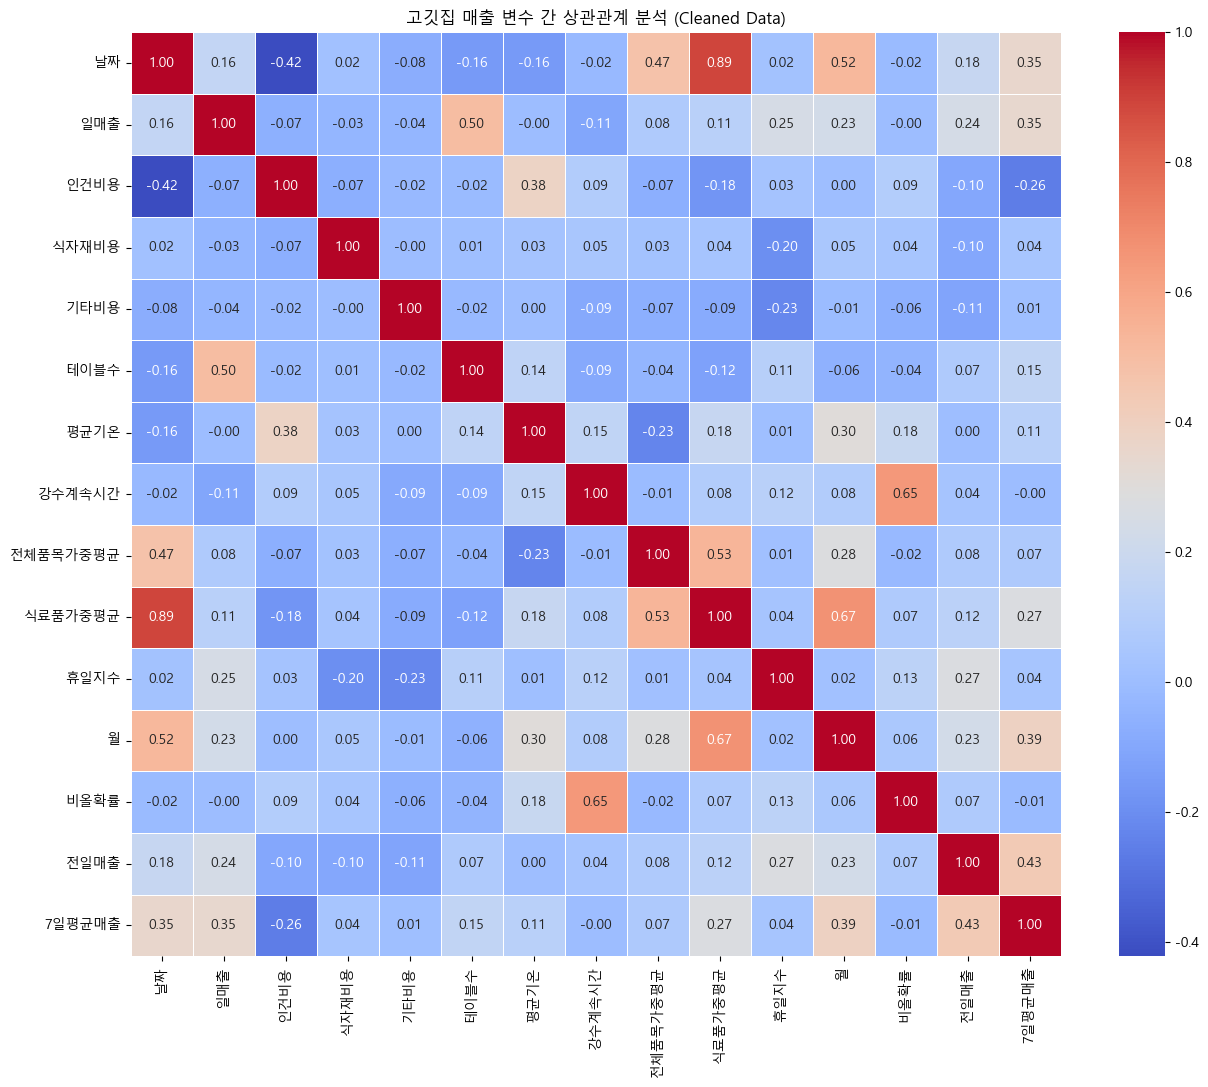

In [65]:
# 1. 상관계수 행렬 계산
corr_matrix = final_df.corr()

# 2. 히트맵 시각화
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('고깃집 매출 변수 간 상관관계 분석 (Cleaned Data)')
plt.show()

In [66]:
# !pip install xgboost

--- 모델 평가 결과 ---
R2 Score (설명력): 0.1344 (1에 가까울수록 완벽)
MAE (평균 절대 오차): 649,713원
RMSE (제곱근 평균 제곱 오차): 830,989원


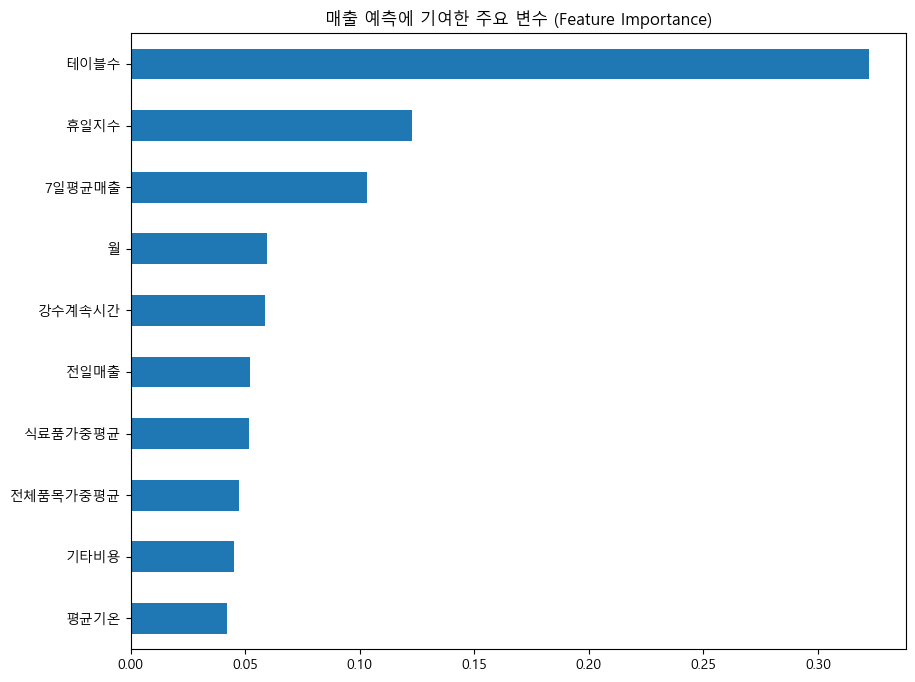

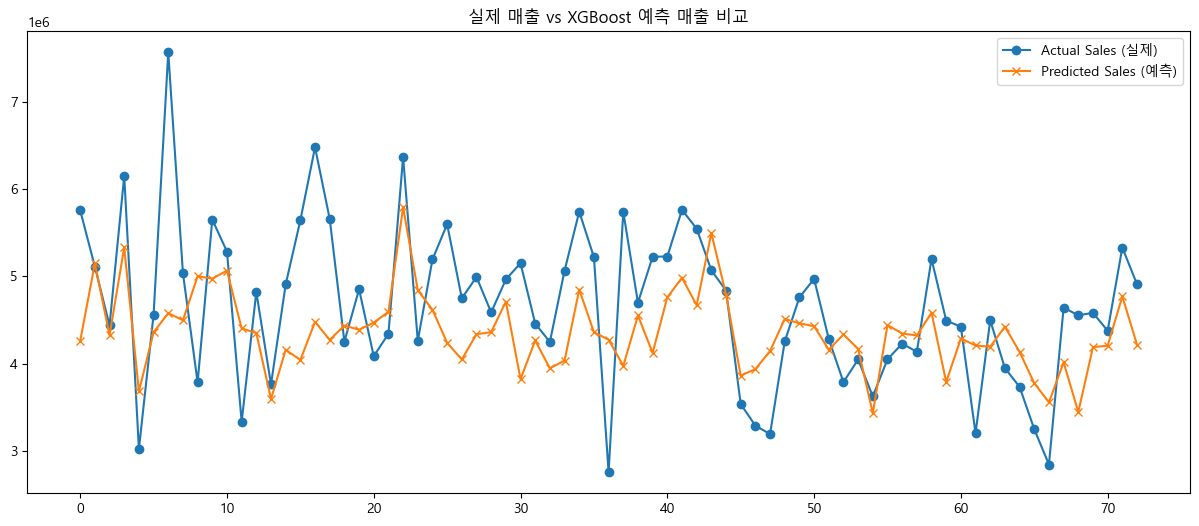

In [67]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. 학습에 사용할 피처(X)와 타겟(y) 설정
# 제외할 목록 : '날짜' -> 인덱스, '일매출' -> 종속변수 
features = ['인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
             '전체품목가중평균', '식료품가중평균', '휴일지수', '월', '비올확률', '전일매출', '7일평균매출']

X = final_df[features]
y = final_df['일매출']

# 2. 학습/테스트 데이터 분리
# 과거 데이터로 미래를 예측 -> shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. XGBoost 모델 생성 및 학습
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 4. 예측 및 성능 평가
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- 모델 평가 결과 ---")
print(f"R2 Score (설명력): {r2:.4f} (1에 가까울수록 완벽)")
print(f"MAE (평균 절대 오차): {mae:,.0f}원")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:,.0f}원")

# 5. 변수 중요도 시각화 (XGBoost가 무엇을 보고 판단했는가?)
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('매출 예측에 기여한 주요 변수 (Feature Importance)')
plt.show()

# 6. 실제 매출 vs 예측 매출 비교 그래프
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Actual Sales (실제)', marker='o')
plt.plot(y_pred, label='Predicted Sales (예측)', marker='x')
plt.title('실제 매출 vs XGBoost 예측 매출 비교')
plt.legend()
plt.show()